# Cat Adoption Prediction

### Project Goal and Question

This notebook develops a machine learning model that estimates whether a cat is likely to be adopted.

### Project question
**Can we use information available when a cat enters the shelter to estimate its probability of adoption?**

The analysis follows a complete ML workflow:
1. Load and inspect the shelter data
2. Isolate cat records and check data quality
3. Clean and prepare variables
4. Engineer the prediction target and model features
5. Encode categorical variables and split the data
6. Train and evaluate several classification models
7. Compare their performance;
8. Use the selected model to generate adoption probabilities


### Import libraries and Data loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
from google.colab import files

uploaded = files.upload()

Saving export.csv to export.csv


### Overview

In [3]:
df = pd.read_csv('export.csv')

In [4]:
df.head()

,ID,Outcome Date,Animal ID,Name,Outcome Status,Euthanasia Reason,Type,Sex,Spayed/Neutered,Primary Breed,Primary Color,Secondary Color,Date of Birth,Intake Date,Days in Shelter,Timestamp
0,94761,2026 Sep 11 06:58:21 PM,31530,Mavis,Adopted,NaN,Kitten,Female,Yes,Domestic Shorthair,Brown Tabby,NaN,2026 Jun 18 12:00:00 AM,2026 Aug 13 12:28:00 PM,29,2026 Sep 12 12:15:10 AM
1,94760,2026 Sep 11 06:50:58 PM,32564,Ariana Poquito,Adopted,NaN,Kitten,Female,Yes,Domestic Shorthair,Brown Tabby,Brown Tabby,2026 Aug 01 12:00:00 AM,2026 Sep 04 03:36:00 PM,7,2026 Sep 12 12:15:10 AM
2,94756,2026 Sep 11 06:34:42 PM,32752,Pepper,Adopted,NaN,Kitten,Male,Yes,Domestic Medium Hair,Black,NaN,2026 Jul 22 12:00:00 AM,2026 Sep 09 03:04:00 PM,2,2026 Sep 12 12:15:10 AM
3,94754,2026 Sep 11 06:29:00 PM,32881,NaN,Transfer Out,NaN,Kitten,Unknown,Unknown,Domestic Shorthair,Black,White,2026 Aug 28 12:00:00 AM,2026 Sep 11 02:46:00 PM,0,2026 Sep 12 12:15:10 AM
4,94753,2026 Sep 11 06:29:00 PM,32886,NaN,Transfer Out,NaN,Kitten,Unknown,Unknown,Domestic Shorthair,Orange Tabby,Orange Tabby,2026 Sep 08 12:00:00 AM,2026 Sep 11 05:17:00 PM,0,2026 Sep 12 12:15:10 AM


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17126 entries, 0 to 17125
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 17126 non-null  int64 
 1   Outcome Date       17126 non-null  object
 2   Animal ID          17126 non-null  int64 
 3   Name               10268 non-null  object
 4   Outcome Status     17126 non-null  object
 5   Euthanasia Reason  1072 non-null   object
 6   Type               17126 non-null  object
 7   Sex                17097 non-null  object
 8   Spayed/Neutered    17111 non-null  object
 9   Primary Breed      17126 non-null  object
 10  Primary Color      17126 non-null  object
 11  Secondary Color    8954 non-null   object
 12  Date of Birth      15819 non-null  object
 13  Intake Date        17126 non-null  object
 14  Days in Shelter    17126 non-null  object
 15  Timestamp          17126 non-null  object
dtypes: int64(2), object(14)
memory usage: 2.

In [6]:
# how many cats
df['Type'].value_counts()

,count
Type,
Cat,7899
Dog,6106
Kitten,1882
Mammal,633
Puppy,336
Rabbit,71
Guinea Pig,44
Bird (wildlife),30
Bird,26


In [7]:
# filter cats
cats = df[df['Type'].isin(['Cat', 'Kitten'])].copy()

In [8]:
# unique cats vs rows to understand if each row = unique animal

print(f'Unique cats: {cats['Animal ID'].nunique()}')
print(f'Rows: {len(cats)}')

Unique cats: 9557
Rows: 9781


In [9]:
# duplicated or not?
cats[cats['Animal ID'].duplicated(keep=False)].sort_values('Animal ID').head(5)

,ID,Outcome Date,Animal ID,Name,Outcome Status,Euthanasia Reason,Type,Sex,Spayed/Neutered,Primary Breed,Primary Color,Secondary Color,Date of Birth,Intake Date,Days in Shelter,Timestamp
15143,24466,2025 Jun 29 01:09:35 PM,5945,Skittles,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Torbie,NaN,2014 Apr 19 12:00:00 AM,2025 Apr 14 12:00:00 AM,76,2026 Sep 12 12:16:57 AM
14935,25398,2025 Jul 03 04:34:51 PM,5945,Skittles,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Torbie,NaN,2014 Apr 19 12:00:00 AM,2025 Jul 02 12:47:00 PM,1,2026 Sep 12 12:16:55 AM
14513,27153,2025 Jul 12 04:28:48 PM,6053,Fritz,Adopted,NaN,Cat,Male,Yes,Domestic Shorthair,Brown Tabby,NaN,2019 Jul 08 12:00:00 AM,2024 Jul 08 12:00:00 AM,369,2026 Sep 12 12:16:53 AM
5453,69247,2026 Apr 24 08:55:00 AM,6053,Fritz,Unassisted Death - In Foster,NaN,Cat,Male,Yes,Domestic Shorthair,Brown Tabby,NaN,2019 Jul 08 12:00:00 AM,2025 Dec 30 06:38:00 PM,115,2026 Sep 12 12:15:42 AM
15383,22917,2025 Jun 22 03:06:01 PM,6098,Jimmy Buffett,Adopted,NaN,Cat,Male,Yes,Domestic Shorthair,Cream Ginger Tabby,NaN,2023 Oct 14 12:00:00 AM,2025 Apr 30 12:00:00 AM,53,2026 Sep 12 12:16:59 AM


In [10]:
# looks like some cats have ended up at the shelter multiple times rather than being duplicates
episode_counts = (cats.groupby(['Animal ID', 'Intake Date', 'Outcome Date', 'Outcome Status']).size())

episode_counts[episode_counts > 1]

,,,,0
Animal ID,Intake Date,Outcome Date,Outcome Status,


### Cleaning

In [11]:
# cat status
cats['Outcome Status'].value_counts()

,count
Outcome Status,
Adopted,4760
Transfer Out,3256
Euthanized,424
Adopted Altered,417
Reclaimed,273
Return to Habitat,260
Unassisted Death,117
DOA,99
Adopted Offsite(Altered),60


In [12]:
# new outcome status

outcome_mapping = {
    'Adopted' : 'Adopted',
    'Adopted Altered' : 'Adopted',
    'Adopted Offsite(Altered)': 'Adopted',
    'Adopted Offsite' : 'Adopted',
    'Adopted Unaltered' : 'Adopted',
    'Adopted Offsite(Unaltered)' : 'Adopted',
    'Adopted to Finder' : 'Adopted',

    'Reclaimed' : 'Returned to owner',
    'Redemption (Offsite)' : 'Returned to owner',

    'Return to Habitat' : 'Return to habitat',

    'Euthanized' : 'Death',
    'Euthanasia - RTO' : 'Death',
    'Unassisted Death' : 'Death',
    'Unassisted Death - In Foster' : 'Death',
    'Unassisted Death - In Transit' : 'Death',
    'DOA' : 'Death',
    'DOA - Released to Owner' : 'Death',
    'DOA - Final Disposition' : 'Death',
    'Cremated' : 'Death',
    'Interred' : 'Death',

    'Transfer Out' : 'Transferred',

    'Lost' : 'Unknown',
    'Escaped' : 'Unknown',
    'Unresolved File' : 'Unknown',

    'Bite Quarantine (Home)' : 'Quarantine'
}

cats['Outcome'] = cats['Outcome Status'].map(outcome_mapping)
cats['Outcome'].value_counts()

,count
Outcome,
Adopted,5276
Transferred,3256
Death,695
Returned to owner,283
Return to habitat,260
Unknown,10
Quarantine,1


In [13]:
# cat sex
cats['Sex'].value_counts()

,count
Sex,
Female,4270
Male,4149
Unknown,1355


In [14]:
# cat sterilization status

cats['Spayed/Neutered'].value_counts()

,count
Spayed/Neutered,
Yes,4666
No,2198
Unknown,1591
yes,1321


In [15]:
# new sterilization status
cats['Spayed/Neutered'] = cats['Spayed/Neutered'].replace('yes', 'Yes')
cats['Spayed/Neutered'].value_counts()

,count
Spayed/Neutered,
Yes,5987
No,2198
Unknown,1591


In [16]:
# cat breed

cats['Primary Breed'].value_counts()

,count
Primary Breed,
Domestic Shorthair,8720
Domestic Medium Hair,640
Domestic Long Hair,204
Siamese,129
Russian,26
American Shorthair,13
Persian,10
Maine Coon,8
Sphynx,7


In [17]:
# new cat breed
cats['Primary Breed'] = cats['Primary Breed'].replace({'RUSSIAN BLUE': 'Russian Blue', 'BRITISH SH': 'British Shorthair'})

cats['Primary Breed'].value_counts()

,count
Primary Breed,
Domestic Shorthair,8720
Domestic Medium Hair,640
Domestic Long Hair,204
Siamese,129
Russian,26
American Shorthair,13
Persian,10
Maine Coon,8
Sphynx,7


In [18]:
# cat color
cats['Primary Color'].unique()

array(['Brown Tabby', 'Black', 'Orange Tabby', 'Smoke', 'Blue',
       'Grey Tabby', 'Calico', 'Grey', 'Cream', 'Tortoiseshell',
       'Muted Tortoiseshell', 'White', 'Lilac', 'Torbie', 'Brown',
       'Buff Tiger', 'Tabby', 'Orange', 'Ginger Tabby', 'Lilac Point',
       'Cream Ginger Tabby', 'Flame Point', 'Smoke Tabby', 'Buff',
       'Seal Point', 'Torti Point Bicolor', 'Silver', 'Lilac Bicolor',
       'BLUE TABBY', 'Silver Tortoiseshell', 'LYNX PT', 'Brown Ticked',
       'Muted Calico', 'Brown Tiger', 'Silver Tabby', 'Smoke Calico',
       'Tabby Point', 'Torti Point', 'Black Tortoiseshell', 'Unknown',
       'Blue Cream Calico', 'Blue Cream Tortoiseshell', 'Apricot',
       'Blue Point', 'Snow Tabby', 'Orange Tiger',
       'Silver Tortoiseshell Calico', 'Champagne', 'Chocolate',
       'Blue Ticked', 'Grey Tiger', 'Chocolate Point', 'Seal Bicolor',
       'Chocolate Calico', 'Fawn Ticked', 'Point', 'Shaded',
       'Lilac Ticked', 'Smoke Tortoiseshell', 'Ticked',
       'Silv

In [19]:
# new cat color
cats['Primary Color'] = cats['Primary Color'].replace({'BLUE TABBY': 'Blue Tabby', 'LYNX PT': 'Lynx Point'})

cats['Primary Color'].unique()

array(['Brown Tabby', 'Black', 'Orange Tabby', 'Smoke', 'Blue',
       'Grey Tabby', 'Calico', 'Grey', 'Cream', 'Tortoiseshell',
       'Muted Tortoiseshell', 'White', 'Lilac', 'Torbie', 'Brown',
       'Buff Tiger', 'Tabby', 'Orange', 'Ginger Tabby', 'Lilac Point',
       'Cream Ginger Tabby', 'Flame Point', 'Smoke Tabby', 'Buff',
       'Seal Point', 'Torti Point Bicolor', 'Silver', 'Lilac Bicolor',
       'Blue Tabby', 'Silver Tortoiseshell', 'Lynx Point', 'Brown Ticked',
       'Muted Calico', 'Brown Tiger', 'Silver Tabby', 'Smoke Calico',
       'Tabby Point', 'Torti Point', 'Black Tortoiseshell', 'Unknown',
       'Blue Cream Calico', 'Blue Cream Tortoiseshell', 'Apricot',
       'Blue Point', 'Snow Tabby', 'Orange Tiger',
       'Silver Tortoiseshell Calico', 'Champagne', 'Chocolate',
       'Blue Ticked', 'Grey Tiger', 'Chocolate Point', 'Seal Bicolor',
       'Chocolate Calico', 'Fawn Ticked', 'Point', 'Shaded',
       'Lilac Ticked', 'Smoke Tortoiseshell', 'Ticked',
       'S

In [20]:
# cat secondary color
cats['Secondary Color'].value_counts()

,count
Secondary Color,
White,2769
Black,421
Brown Tabby,202
Tabby,150
Grey,90
Orange Tabby,76
Brown,63
Blue,60
Cream,40


In [21]:
# new cat secondary color

cats['Secondary Color'] = cats['Secondary Color'].replace({'BLUE TABBY': 'Blue Tabby', 'LYNX PT': 'Lynx Point'})

cats['Secondary Color'].unique()

array([nan, 'Brown Tabby', 'White', 'Orange Tabby', 'Black', 'Smoke',
       'Tabby', 'Tortoiseshell', 'Grey', 'Brown', 'Muted Calico',
       'Cream Ginger Tabby', 'Cream', 'Calico', 'Red Shaded',
       'Grey Tabby', 'Silver Shaded', 'Black Tortoiseshell', 'Orange',
       'Chocolate', 'Lynx Point', 'Silver Tabby', 'Patch Tabby', 'Lilac',
       'Torbie', 'Blue', 'Orange Tiger', 'Seal Point', 'Lilac Point',
       'Flame Point', 'Brown Ticked', 'Apricot', 'Blue Point',
       'Blue Tabby', 'Brown Tiger', 'Ginger Tabby', 'Chocolate Tabby',
       'Buff', 'Torti Point', 'Silver Tortoiseshell', 'Champagne',
       'Tabby Point', 'Ginger'], dtype=object)

In [22]:
# cat age at intake (months)

cats['Date of Birth'] = pd.to_datetime(cats['Date of Birth'])
cats['Intake Date'] = pd.to_datetime(cats['Intake Date'])

cats['Age at Intake'] = ((cats['Intake Date'].dt.year - cats['Date of Birth'].dt.year) * 12 + (
    cats['Intake Date'].dt.month - cats['Date of Birth'].dt.month))

cats[['Date of Birth', 'Intake Date', 'Age at Intake']].head(5)

/tmp/ipykernel_591/367399786.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cats['Date of Birth'] = pd.to_datetime(cats['Date of Birth'])


,Date of Birth,Intake Date,Age at Intake
0,2026-06-18,2026-08-13 12:28:00,2.0
1,2026-08-01,2026-09-04 15:36:00,1.0
2,2026-07-22,2026-09-09 15:04:00,2.0
3,2026-08-28,2026-09-11 14:46:00,1.0
4,2026-09-08,2026-09-11 17:17:00,0.0


In [23]:
cats['Age at Intake'].describe()

,Age at Intake
count,9300.000000
mean,14.445484
std,25.592985
min,-1.000000
25%,1.000000
50%,3.000000
75%,23.000000
max,216.000000


In [24]:
# checking rows with strange values
cats[cats['Age at Intake'] < 0][['Animal ID', 'Date of Birth', 'Intake Date', 'Age at Intake']]

,Animal ID,Date of Birth,Intake Date,Age at Intake
2371,29732,2026-07-02,2026-06-15 14:22:00,-1.0
9706,12678,2025-08-22,2025-07-24 11:47:00,-1.0
10463,12677,2025-08-22,2025-07-24 11:47:00,-1.0
10904,12874,2025-08-06,2025-07-28 15:58:00,-1.0
11007,12875,2025-08-06,2025-07-28 15:58:00,-1.0
12935,6767,2025-05-23,2025-04-30 00:00:00,-1.0
15544,8908,2025-06-02,2025-05-25 17:22:00,-1.0
15545,8907,2025-06-02,2025-05-25 17:22:00,-1.0
15546,8906,2025-06-02,2025-05-25 17:22:00,-1.0
15547,8905,2025-06-02,2025-05-25 17:22:00,-1.0


In [25]:
# replace to nan

cats['Age at Intake'] = cats['Age at Intake'].replace(-1, np.nan)

cats['Age at Intake'].describe()

,Age at Intake
count,9288.000000
mean,14.465439
std,25.603488
min,0.000000
25%,1.000000
50%,3.000000
75%,23.000000
max,216.000000


In [26]:
# cat days in shelter
cats['Days in Shelter'].describe()

,Days in Shelter
count,9781
unique,228
top,0
freq,1033


In [27]:
cats['Days in Shelter'] = pd.to_numeric(cats['Days in Shelter'])

cats['Days in Shelter'].describe()

,Days in Shelter
count,9781.000000
mean,21.723137
std,34.802091
min,0.000000
25%,4.000000
50%,8.000000
75%,29.000000
max,733.000000


In [28]:
# missing

cats.isna().sum()

,0
ID,0
Outcome Date,0
Animal ID,0
Name,4779
Outcome Status,0
Euthanasia Reason,9327
Type,0
Sex,7
Spayed/Neutered,5
Primary Breed,0


In [29]:
# fill na
cats['Sex'] = cats['Sex'].fillna('Unknown')
cats['Spayed/Neutered'] = cats['Spayed/Neutered'].fillna('Unknown')
cats['Secondary Color'] = cats['Secondary Color'].fillna('Unknown')

cats[['Sex', 'Spayed/Neutered', 'Secondary Color']].isna().sum()

,0
Sex,0
Spayed/Neutered,0
Secondary Color,0


In [30]:
# i can't fill Age at Intake with the median coz the predictive model might produce skewed results.
# thats why i'm creating a separate column where I explicitly indicate if this is a known age or a value filled

cats['Age Unknown'] = cats['Age at Intake'].isna().astype(int)
cats['Age at Intake'] = cats['Age at Intake'].fillna(cats['Age at Intake'].median())

cats[['Animal ID', 'Age at Intake', 'Age Unknown']].head(5)

,Animal ID,Age at Intake,Age Unknown
0,31530,2.0,0
1,32564,1.0,0
2,32752,2.0,0
3,32881,1.0,0
4,32886,0.0,0


In [31]:
# the remaining missing values are not filled in because there is no need or way to do so
cats.isna().sum()

,0
ID,0
Outcome Date,0
Animal ID,0
Name,4779
Outcome Status,0
Euthanasia Reason,9327
Type,0
Sex,0
Spayed/Neutered,0
Primary Breed,0


### Feature Engineering & Data Preparation

Our target variable is **whether a cat will be adopted or not**. Since this is a binary classification problem, we need to convert the adoption outcome into a binary variable that can be used as the target for our models.

We also want to use the **intake date** as one of our features. Instead of using the full date, we extract the **intake month** and convert it into a numerical value. This allows the models to use information about the time of year when the cat entered the shelter.

In [32]:
# adopted binary column and balance checking

cats['Adopted'] = (cats['Outcome'] == 'Adopted').astype(int)

cats['Adopted'].value_counts()

,count
Adopted,
1,5276
0,4505


In [33]:
# month from date of intake

cats['Intake Month'] = cats['Intake Date'].dt.month

cats['Intake Month'].value_counts()

,count
Intake Month,
6,1850
5,1683
7,1221
8,1079
4,787
10,667
9,657
3,449
2,365


In [34]:
cats.columns

Index(['ID', 'Outcome Date', 'Animal ID', 'Name', 'Outcome Status',
       'Euthanasia Reason', 'Type', 'Sex', 'Spayed/Neutered', 'Primary Breed',
       'Primary Color', 'Secondary Color', 'Date of Birth', 'Intake Date',
       'Days in Shelter', 'Timestamp', 'Outcome', 'Age at Intake',
       'Age Unknown', 'Adopted', 'Intake Month'],
      dtype='object')

#### Feature Selection

**Categorical features:**
- `Type`
- `Sex`
- `Spayed/Neutered`
- `Primary Breed`
- `Primary Color`
- `Secondary Color`
- `Intake Month`

**Numerical features:**
- `Age at Intake`
- `Age Unknown`

#### Target
- `Adopted`

#### Not used
- `ID`
- `Animal ID`
- `Name`
- `Outcome Status`
- `Euthanasia Reason`
- `Outcome Date`
- `Date of Birth`
- `Intake Date`
- `Days in Shelter`
- `Timestamp`
- `Outcome`

In [35]:
# checking unique values in each column before creating dummy variables
cats[['Type', 'Sex', 'Spayed/Neutered', 'Primary Breed',
      'Primary Color', 'Secondary Color', 'Intake Month']].nunique()

,0
Type,2
Sex,3
Spayed/Neutered,3
Primary Breed,19
Primary Color,62
Secondary Color,43
Intake Month,12


In [36]:
cats['Primary Color'].value_counts().tail(25)

,count
Primary Color,
Silver Tortoiseshell,5
Smoke Tabby,5
Snow Tabby,4
Lilac,4
Chocolate Point,4
Brown Ticked,4
Orange Tiger,3
Smoke Tortoiseshell,3
Torti Point Bicolor,2


In [37]:
# some color categories very rare, with fewer than 5 observations. rare categories were grouped into 'Other'
# 'Unknown' category was kept separately. it represents missing/unknown information rather than a known but uncommon color

pr_color_counts = cats['Primary Color'].value_counts()

pr_rare_colors = pr_color_counts[(pr_color_counts < 5) & (pr_color_counts.index != 'Unknown')].index

cats['Primary Color'] = cats['Primary Color'].replace(pr_rare_colors, 'Other')

In [38]:
cats['Secondary Color'].value_counts().tail(25)

,count
Secondary Color,
Seal Point,7
Flame Point,7
Black Tortoiseshell,6
Muted Calico,5
Lynx Point,4
Lilac Point,4
Patch Tabby,4
Lilac,3
Red Shaded,2


In [39]:
# some color categories very rare, with fewer than 5 observations. rare categories were grouped into 'Other'
# 'Unknown' category was kept separately. it represents missing/unknown information rather than a known but uncommon color

sec_color_counts = cats['Secondary Color'].value_counts()

sec_rare_colors = sec_color_counts[(sec_color_counts < 5) & (sec_color_counts.index != 'Unknown')].index

cats['Secondary Color'] = cats['Secondary Color'].replace(sec_rare_colors, 'Other')

In [40]:
cats[['Type', 'Sex', 'Spayed/Neutered', 'Primary Breed',
      'Primary Color', 'Secondary Color', 'Intake Month']].nunique()

,0
Type,2
Sex,3
Spayed/Neutered,3
Primary Breed,19
Primary Color,41
Secondary Color,23
Intake Month,12


### Data encoding

In [41]:
# create new df
cats_encoded = cats[['Animal ID', 'Type', 'Sex', 'Spayed/Neutered', 'Primary Breed',
                     'Primary Color', 'Secondary Color', 'Intake Month', 'Age at Intake',
                     'Age Unknown', 'Adopted']].copy()

In [42]:
# dummies
categorical_cols = ['Type', 'Sex', 'Spayed/Neutered', 'Primary Breed', 'Primary Color',
                    'Secondary Color', 'Intake Month']

cats_encoded = pd.get_dummies(cats_encoded, columns=categorical_cols, dtype=int)

cats_encoded.head(2)

,Animal ID,Age at Intake,Age Unknown,Adopted,Type_Cat,Type_Kitten,Sex_Female,Sex_Male,Sex_Unknown,Spayed/Neutered_No,...,Intake Month_3,Intake Month_4,Intake Month_5,Intake Month_6,Intake Month_7,Intake Month_8,Intake Month_9,Intake Month_10,Intake Month_11,Intake Month_12
0,31530,2.0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,32564,1.0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### Test train

Before training the models, we divide the data into separate subsets.

- **Training data** is used to fit the models.
- **Validation data** is used to choose hyperparameters.
- **Test data** is kept aside until the final evaluation.

In [43]:
# get x y

y = cats_encoded['Adopted']
X = cats_encoded.drop(columns=['Animal ID', 'Adopted'])


In [44]:
# test train

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 1,
    stratify=y        # save proportion in test/train for Adopted
)

print('Original:')
print(y.value_counts(normalize=True))

print('\nTrain:')
print(y_train.value_counts(normalize=True))

print('\nTest:')
print(y_test.value_counts(normalize=True))

Original:
Adopted
1    0.539413
0    0.460587
Name: proportion, dtype: float64

Train:
Adopted
1    0.539439
0    0.460561
Name: proportion, dtype: float64

Test:
Adopted
1    0.539353
0    0.460647
Name: proportion, dtype: float64


In [45]:
# train -> train validation

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.3,
    random_state=1,
    stratify=y_train
)

print('Original:')
print(y_train.value_counts(normalize=True))

print('\nTrain:')
print(y_train_model.value_counts(normalize=True))

print('\nTest:')
print(y_val.value_counts(normalize=True))

Original:
Adopted
1    0.539439
0    0.460561
Name: proportion, dtype: float64

Train:
Adopted
1    0.539441
0    0.460559
Name: proportion, dtype: float64

Test:
Adopted
1    0.539435
0    0.460565
Name: proportion, dtype: float64


### Scaling

In [46]:
# scaling Age at Intake

scaler = StandardScaler()
scaler.fit(X_train_model[['Age at Intake']])

X_train_model_scaled = X_train_model.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_model_scaled[['Age at Intake']] = scaler.transform(X_train_model[['Age at Intake']])

X_val_scaled[['Age at Intake']] = scaler.transform(X_val[['Age at Intake']])

X_test_scaled[['Age at Intake']] = scaler.transform(X_test[['Age at Intake']])

### Logistic Regression + L2 (Ridge)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


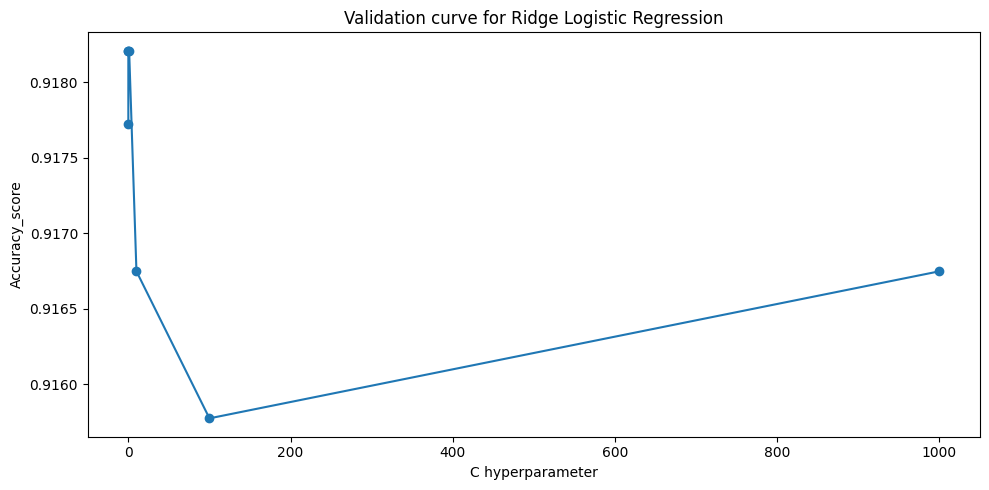

In [47]:
# search best hyperparameter

possible_C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
accuracy_scores = []

for C in possible_C:
  model = LogisticRegression(C=C, penalty='l2')
  model.fit(X_train_model_scaled, y_train_model)
  y_pred = model.predict(X_val_scaled)
  accuracy_scores.append(accuracy_score(y_val, y_pred))

plt.figure(figsize=(10,5))
plt.plot(possible_C, accuracy_scores, marker = 'o')
plt.xlabel('C hyperparameter')
plt.ylabel('Accuracy_score')
plt.title('Validation curve for Ridge Logistic Regression')
plt.tight_layout()
plt.show()

In [48]:
print(f'Accuracy: {accuracy_scores}')

Accuracy: [0.9177215189873418, 0.9182083739045764, 0.9182083739045764, 0.9182083739045764, 0.9167478091528725, 0.9157740993184031, 0.9167478091528725]


To find the optimal regularization strength, I tested different values of the `C` hyperparameter and evaluated the model on the validation set using accuracy.

The highest validation accuracy (0.9182) was achieved with `C = 0.01`, `C = 0.1`, and `C = 1`.

Since all three values produced the same result, I selected `C = 0.01` because a smaller `C` applies stronger regularization and helps reduce the risk of overfitting.

In [49]:
# logistic regression l2 c=0.01

X_train_final = pd.concat([X_train_model_scaled, X_val_scaled])
y_train_final = pd.concat([y_train_model, y_val])

ridge_model = LogisticRegression(C=0.01, penalty='l2')
ridge_model.fit(X_train_final, y_train_final)
y_pred_ridge = ridge_model.predict(X_test_scaled)

In [50]:
# feature importance

coefficients = ridge_model.coef_[0]
feature_names = X_train_final.columns

ridge_importance = pd.DataFrame ({'Feature':feature_names, 'Importance':coefficients}).sort_values(by='Importance')

print(ridge_importance)

                    Feature  Importance
7        Spayed/Neutered_No   -1.371727
8   Spayed/Neutered_Unknown   -0.911179
6               Sex_Unknown   -0.622076
0             Age at Intake   -0.454709
1               Age Unknown   -0.286429
..                      ...         ...
99           Intake Month_7    0.101965
2                  Type_Cat    0.164905
5                  Sex_Male    0.283018
4                Sex_Female    0.339596
9       Spayed/Neutered_Yes    2.283444

[105 rows x 2 columns]


In [51]:
# top 20 features (head and tail)

best = ridge_importance.tail(10)
worst = ridge_importance.head(10)

features = pd.concat([best, worst]).sort_values(by='Importance')
features

,Feature,Importance
7,Spayed/Neutered_No,-1.371727
8,Spayed/Neutered_Unknown,-0.911179
6,Sex_Unknown,-0.622076
0,Age at Intake,-0.454709
1,Age Unknown,-0.286429
3,Type_Kitten,-0.164367
104,Intake Month_12,-0.117893
95,Intake Month_3,-0.105029
70,Secondary Color_Black,-0.093310
17,Primary Breed_Domestic Shorthair,-0.075431


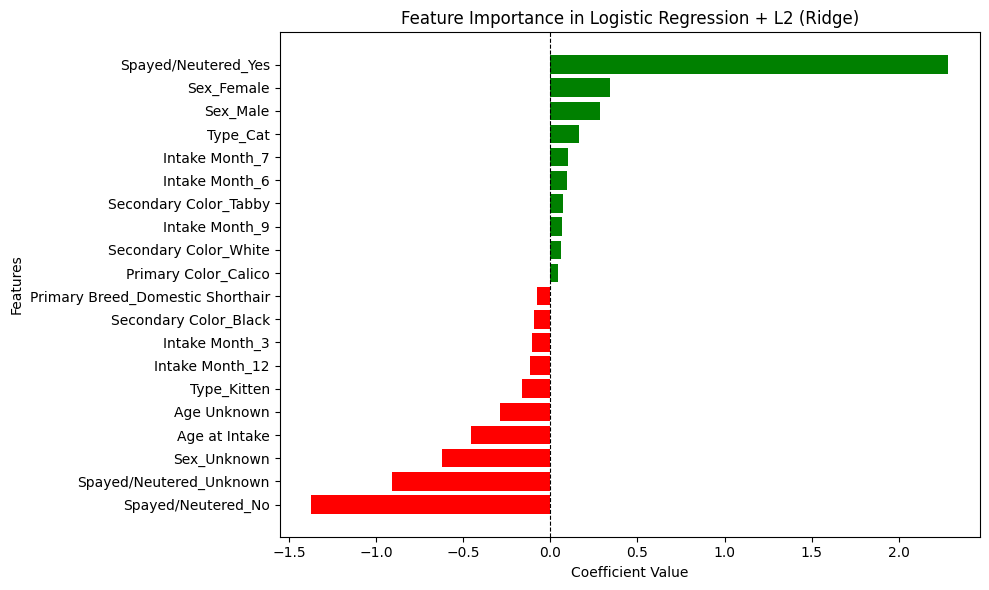

In [52]:
# viz

plt.figure(figsize = (10,6))
colors = ['green' if val > 0 else 'red' for val in features['Importance']]
plt.barh(features['Feature'], features['Importance'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')     # reference line at zero

plt.title('Feature Importance in Logistic Regression + L2 (Ridge)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

**Spay/neuter status** is the strongest factor in the model. "Spayed/Neutered_Yes" has the highest positive coefficient, while "No" and "Unknown" have negative coefficients. This means that spayed or neutered animals in the dataset have a higher predicted probability of being adopted.

**Age at intake** also has a noticeable effect on the prediction. The negative coefficient for Age at Intake indicates that the probability of adoption decreases with increasing age. The Age Unknown category also has a negative coefficient.

**Gender** has a moderate effect. "Female" and "Male" have positive coefficients relative to the base category "Unknown", though the effect of gender is significantly weaker than that of spay/neuter status and age.

**Animal type** has a small effect: "Type_Cat" has a positive coefficient, while "Type_Kitten" is on the opposite side.

The **month of intake** is also associated with the probability of adoption. For example, arrivals in June, July and September have positive coefficients, while some other months have negative ones. However, the effect of the month is relatively small.

**Breed and coat color** generally have small coefficients. Among them are characteristics with both positive and negative associations with adoption, but their influence is significantly weaker than that of the main factors.

In [53]:
# ridge model metrics

print('Accuracy:', accuracy_score(y_test, y_pred_ridge))
print('Precision:', precision_score(y_test, y_pred_ridge))
print('Recall:', recall_score(y_test, y_pred_ridge))
print('F1:', f1_score(y_test, y_pred_ridge))

Accuracy: 0.9202725724020443
Precision: 0.8830210107893243
Recall: 0.9823120656980417
F1: 0.9300239234449761


**Accuracy = 92%**
Accuracy indicates the proportion of all predictions that the model made correctly. In our case, the model correctly classifies about 92% of all animals in the test set.

**Precision = 88.3%**
Precision indicates what proportion of animals that the model predicted as "Adopted" were actually adopted. In our case, if the model predicts that an animal will be adopted, it is correct about 88% of the time.

**Recall = 98.2%**
Recall indicates the proportion of all animals that were actually adopted that the model was able to correctly identify. Our Recall is 98.2%, meaning the model misses very few animals that were actually adopted.

**F1-score = 93%**
The F1-score combines Precision and Recall into a single metric and shows the overall balance between them. A value of 93.0% indicates that the model strikes a good balance between the accuracy of positive predictions and its ability to identify animals that were actually adopted.

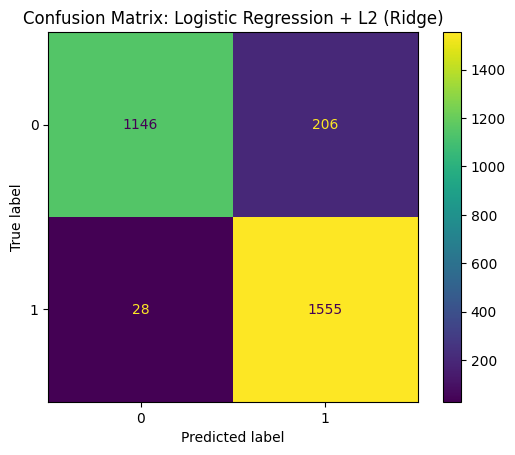

In [54]:
# сonfusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ridge)

plt.title('Confusion Matrix: Logistic Regression + L2 (Ridge)')
plt.show()

The confusion matrix shows which predictions the model made correctly and where it made mistakes:

**True Negative** = 1146 - the model correctly predicted "Not Adopted", and the animal was indeed not adopted.

**True Positive** = 1555 - the model correctly predicted "Adopted", and the animal was indeed adopted.

**False Positive** = 206 - the model predicted "Adopted", but the animal was not actually adopted.

**False Negative** = 28 - the model predicted "Not Adopted", even though the animal was actually adopted.

Overall, the Logistic Regression + L2 (Ridge) model performs very well. The particularly high recall (98.2%) means that the model correctly identifies the vast majority of animals that were actually adopted. However, there are more false positives than false negatives, meaning that the model more often incorrectly predicts an adoption than it fails to identify an animal that was actually adopted.

### Logistic Regression + L1 (Lasso)

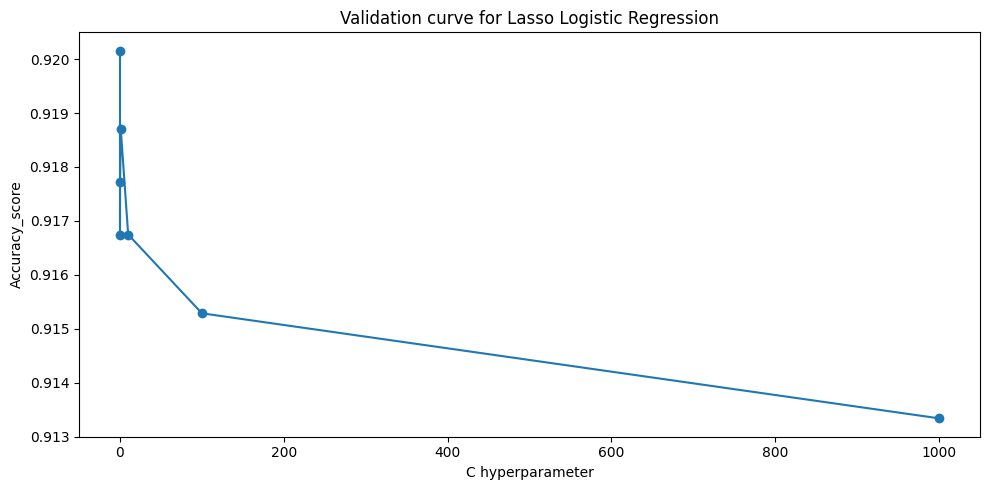

In [55]:
# search best hyperparameter

possible_C = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
accuracy_scores = []

for C in possible_C:
  model = LogisticRegression(C=C, penalty='l1', solver='liblinear')     #liblinear → supports l1
  model.fit(X_train_model_scaled, y_train_model)
  y_pred = model.predict(X_val_scaled)
  accuracy_scores.append(accuracy_score(y_val, y_pred))

plt.figure(figsize=(10,5))
plt.plot(possible_C, accuracy_scores, marker = 'o')
plt.xlabel('C hyperparameter')
plt.ylabel('Accuracy_score')
plt.title('Validation curve for Lasso Logistic Regression')

plt.tight_layout()
plt.show()

In [56]:
print(f'Accuracy: {accuracy_scores}')

Accuracy: [0.9201557935735151, 0.9167478091528725, 0.9177215189873418, 0.9186952288218111, 0.9167478091528725, 0.9152872444011685, 0.9133398247322297]


To find the optimal regularization strength, I tested different values of the `C` hyperparameter and evaluated the model on the validation set using accuracy.

The highest validation accuracy (0.9201) was achieved with `C = 0.001`.

In [57]:
# logistic regression l1 c=0.001

X_train_final = pd.concat([X_train_model_scaled, X_val_scaled])
y_train_final = pd.concat([y_train_model, y_val])

lasso_model = LogisticRegression(C=0.001, penalty='l1', solver='liblinear')
lasso_model.fit(X_train_final, y_train_final)
y_pred_lasso = lasso_model.predict(X_test_scaled)

In [58]:
# feature importance

coefficients = lasso_model.coef_[0]
feature_names = X_train_final.columns

lasso_importance = pd.DataFrame ({'Feature':feature_names, 'Importance':coefficients}).sort_values(by='Importance')

print(lasso_importance)

                 Feature  Importance
0          Age at Intake    0.000000
1            Age Unknown    0.000000
2               Type_Cat    0.000000
3            Type_Kitten    0.000000
4             Sex_Female    0.000000
..                   ...         ...
100       Intake Month_8    0.000000
101       Intake Month_9    0.000000
102      Intake Month_10    0.000000
103      Intake Month_11    0.000000
9    Spayed/Neutered_Yes    0.540867

[105 rows x 2 columns]


In Lasso, only one feature has a non-zero coefficient - **Spayed/Neutered_Yes**. This is the same feature that was the most significant in Ridge as well. The remaining coefficients were set to zero due to strong regularization at C = 0.001. We will not relax the regularization, since this value of C gave a very good result on the validation set (Accuracy = 92%) and when selecting hyperparameters, we prioritize model quality.

In [59]:
# lasso model metrics

print('Accuracy:', accuracy_score(y_test, y_pred_lasso))
print('Precision:', precision_score(y_test, y_pred_lasso))
print('Recall:', recall_score(y_test, y_pred_lasso))
print('F1:', f1_score(y_test, y_pred_lasso))

Accuracy: 0.919931856899489
Precision: 0.8740288568257492
Recall: 0.9949463044851548
F1: 0.930576070901034


**Accuracy**: 91.99% - almost the same as Ridge (92.%).

**Precision**: 87.40% - slightly lower than Ridge (88.3%).

**Recall**: 99.49% - higher than Ridge (98.2%). Lasso is even better at identifying cats that have actually been adopted.

**F1**: 93.06% - practically the same, but slightly higher than Ridge (93%).

Overall, the quality of both models is very similar, though Lasso is better at finding animals that have actually been adopted.

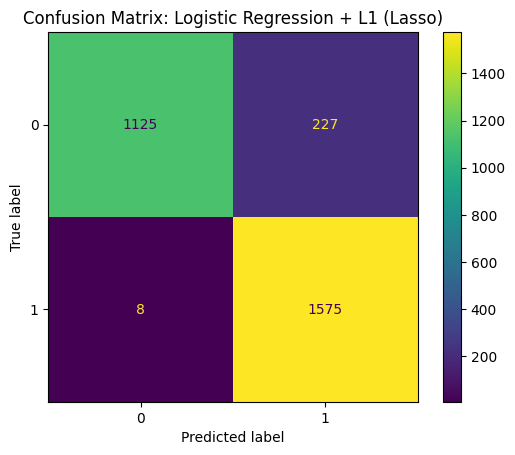

In [60]:
# сonfusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lasso)

plt.title('Confusion Matrix: Logistic Regression + L1 (Lasso)')
plt.show()

The confusion matrix shows which predictions the model made correctly and where it made mistakes:

**True Negative** = 1125 - the model correctly predicted "Not Adopted", and the animal was indeed not adopted.

**True Positive** = 1575 - the model correctly predicted "Adopted", and the animal was indeed adopted.

**False Positive** = 227 - the model predicted "Adopted", but the animal was not actually adopted.

**False Negative** = 8 - the model predicted "Not Adopted", even though the animal was actually adopted.

The very low number of false negatives explains the high Lasso recall 99.49%: the model almost never misses animals that were actually adopted.

### Decision Tree

A Decision Tree learns a sequence of if/then-style splits in the data.

This model is useful here because it can capture non linear relationships and interactions between characteristics without requiring the features to be linearly related to the target.

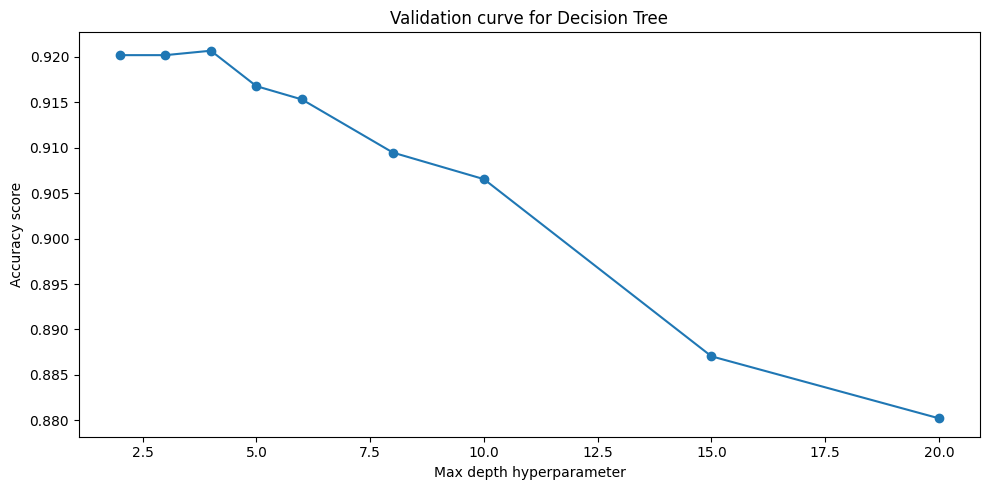

In [61]:
# searching best hyperparameter max_depth

possible_depths = [2, 3, 4, 5, 6, 8, 10, 15, 20]
accuracy_scores_tree = []

for depth in possible_depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=1)
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_val)
    accuracy_scores_tree.append(accuracy_score(y_val, y_pred))

plt.figure(figsize=(10,5))
plt.plot(possible_depths, accuracy_scores_tree, marker = 'o')
plt.xlabel('Max depth hyperparameter')
plt.ylabel('Accuracy score')
plt.title('Validation curve for Decision Tree')

plt.tight_layout()
plt.show()

In [62]:
print(f'Accuracy: {accuracy_scores_tree}')

Accuracy: [0.9201557935735151, 0.9201557935735151, 0.9206426484907497, 0.9167478091528725, 0.9152872444011685, 0.9094449853943525, 0.9065238558909445, 0.887049659201558, 0.8802336903602727]


The optimal depth for the decision tree is `max_depth = 4`, at which the accuracy on the validation set was 92.06%. As the depth increases, the model's performance gradually declines; therefore, a more complex tree does not yield any improvement in this case.

In [63]:
# Decision Tree max_depth=4

X_train_final = pd.concat([X_train_model, X_val])
y_train_final = pd.concat([y_train_model, y_val])

tree_model = DecisionTreeClassifier(max_depth=4,random_state=1)
tree_model.fit(X_train_final, y_train_final)
y_pred_tree = tree_model.predict(X_test)

In [64]:
# feature importance

coefficients = tree_model.feature_importances_
feature_names = X_train_final.columns

tree_importance = pd.DataFrame ({'Feature':feature_names, 'Importance':coefficients}).sort_values(by='Importance', ascending=False)

print(tree_importance)

                 Feature  Importance
9    Spayed/Neutered_Yes    0.926436
0          Age at Intake    0.064482
1            Age Unknown    0.004039
6            Sex_Unknown    0.002119
99        Intake Month_7    0.001744
..                   ...         ...
100       Intake Month_8    0.000000
101       Intake Month_9    0.000000
102      Intake Month_10    0.000000
103      Intake Month_11    0.000000
104      Intake Month_12    0.000000

[105 rows x 2 columns]


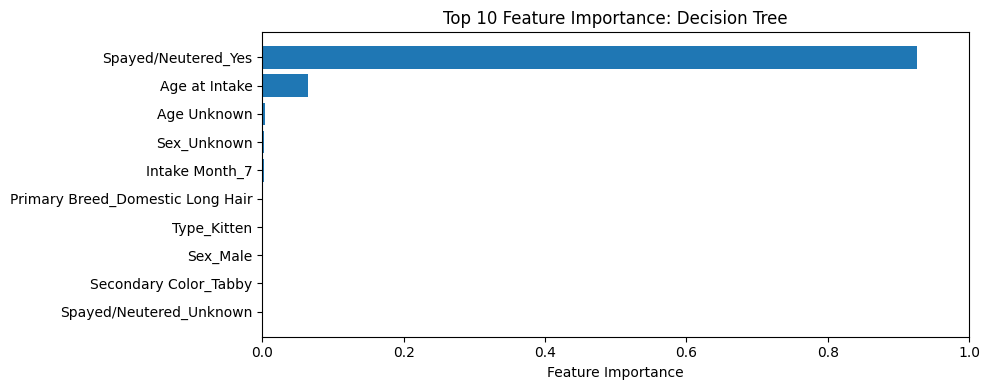

In [65]:
# viz

top_tree = tree_importance.head(10)

plt.figure(figsize=(10,4))
plt.barh(top_tree['Feature'], top_tree['Importance'])
plt.title('Top 10 Feature Importance: Decision Tree')
plt.xlabel('Feature Importance')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Decision Tree also identifies **Spayed/Neutered_Yes** as the most important feature: its importance is 0.926. **Age at Intake** ranks second, with an importance of 0.064. The remaining features are significantly less important and some features are not used by the tree at all. Unlike Logistic Regression, `feature_importances_` shows only the relative importance of features and does not indicate whether a feature increases or decreases the probability of adoption.

In [66]:
# Decision Tree metrics

print('Accuracy:', accuracy_score(y_test, y_pred_tree))
print('Precision:', precision_score(y_test, y_pred_tree))
print('Recall:', recall_score(y_test, y_pred_tree))
print('F1:', f1_score(y_test, y_pred_tree))

Accuracy: 0.9229982964224872
Precision: 0.8818232976927406
Recall: 0.9898926089703095
F1: 0.9327380952380953


The Decision Tree model showed **Accuracy** = 92.3%, **Precision** = 88.18%, **Recall** = 98.99% and **F1** = 93.27%. The model performs slightly better than Ridge, while maintaining a very high Recall of 98.99%.

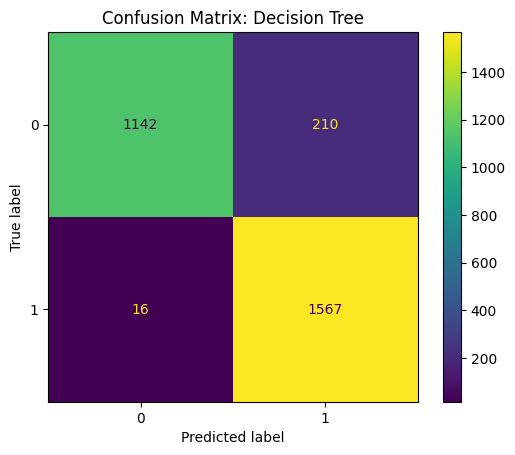

In [67]:
# сonfusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)

plt.title('Confusion Matrix: Decision Tree')
plt.show()

The confusion matrix shows which predictions the model made correctly and where it made mistakes:

**True Negative** = 1142 - the model correctly predicted "Not Adopted", and the animal was indeed not adopted.

**True Positive** = 1567 - the model correctly predicted "Adopted", and the animal was indeed adopted.

**False Positive** = 210 - the model predicted "Adopted", but the animal was not actually adopted.

**False Negative** = 16 - the model predicted "Not Adopted", even though the animal was actually adopted.

The low number of false negatives explains the high recall 98.99% - the model correctly identifies nearly all animals that were actually adopted

### Random Forest

Random Forest combines many decision trees and aggregates their predictions.

The idea is to reduce the instability of a single tree by learning from multiple trees built from different samples/features.

We tune:
- `n_estimators` — the number of trees;
- `max_depth` — the maximum depth of each tree.

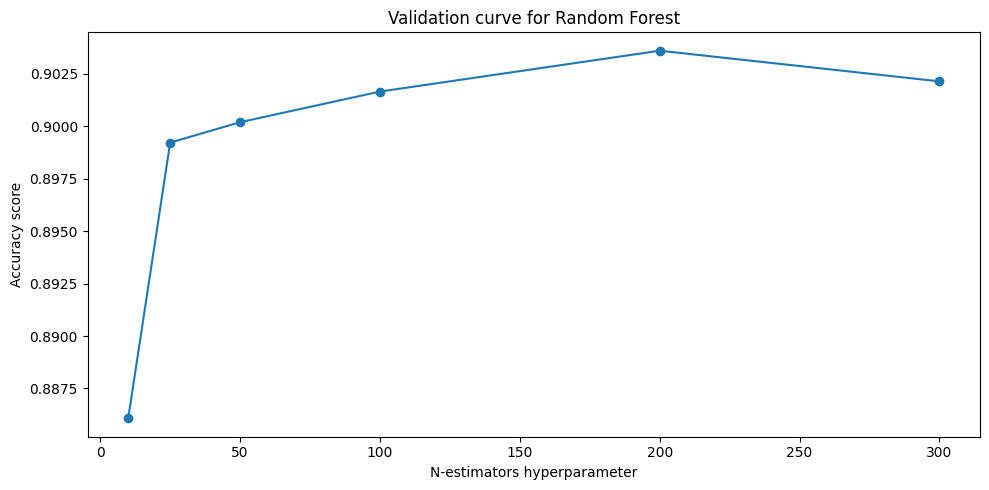

In [68]:
# searching best hyperparameter n_estimators

possible_n_estimators = [10, 25, 50, 100, 200, 300]
accuracy_scores_forest = []

for n in possible_n_estimators:
    model = RandomForestClassifier(n_estimators=n, random_state=1)
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_val)
    accuracy_scores_forest.append(accuracy_score(y_val, y_pred))

plt.figure(figsize=(10,5))
plt.plot(possible_n_estimators, accuracy_scores_forest, marker = 'o')
plt.xlabel('N-estimators hyperparameter')
plt.ylabel('Accuracy score')
plt.title('Validation curve for Random Forest')

plt.tight_layout()
plt.show()

In [69]:
print(f'Accuracy: {accuracy_scores_forest}')

Accuracy: [0.8860759493670886, 0.8992210321324245, 0.9001947419668939, 0.9016553067185978, 0.9036027263875365, 0.9021421616358325]


The optimal value for `n_estimators` is 200, at which the accuracy on the validation set was 90.36%. After 200 trees, increasing the number of trees did not improve the result, so we choose `n_estimators` = 200.

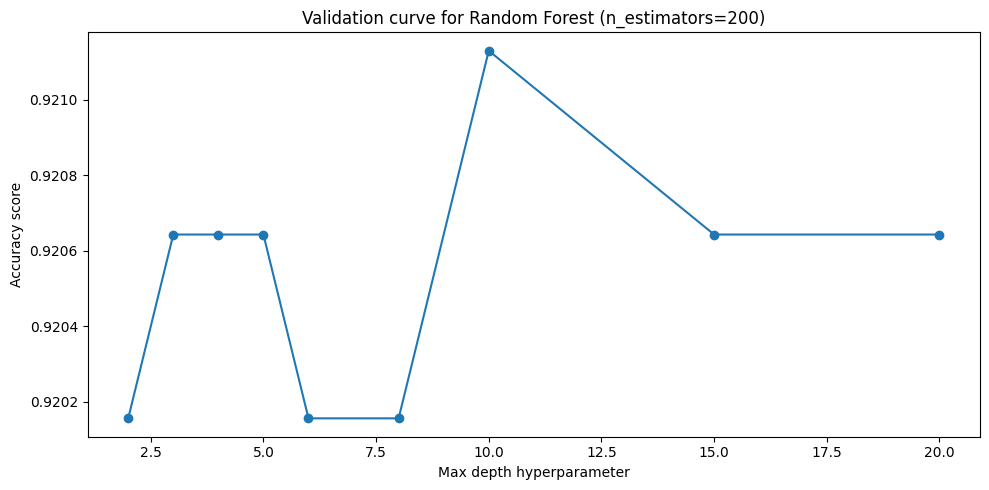

In [70]:
# searching best hyperparameter max_depth

possible_depths_forest = [2, 3, 4, 5, 6, 8, 10, 15, 20]
accuracy_scores_forest_depth = []

for depth in possible_depths_forest:
    model = RandomForestClassifier(n_estimators=200, max_depth=depth, random_state=1)
    model.fit(X_train_model, y_train_model)
    y_pred = model.predict(X_val)
    accuracy_scores_forest_depth.append(accuracy_score(y_val, y_pred))

plt.figure(figsize=(10,5))
plt.plot(possible_depths_forest, accuracy_scores_forest_depth, marker = 'o')
plt.xlabel('Max depth hyperparameter')
plt.ylabel('Accuracy score')
plt.title('Validation curve for Random Forest (n_estimators=200)')

plt.tight_layout()
plt.show()

In [71]:
print(f'Accuracy: {accuracy_scores_forest_depth}')

Accuracy: [0.9201557935735151, 0.9206426484907497, 0.9206426484907497, 0.9206426484907497, 0.9201557935735151, 0.9201557935735151, 0.9211295034079844, 0.9206426484907497, 0.9206426484907497]


The optimal tree depth for Random Forest is `max_depth = 10`, at which the accuracy on the validation set was 92.11%. With a smaller or larger depth, the result is slightly lower, so we choose `max_depth = 10`.

In [72]:
# Random forest max_depth=10, n_estimators=200

X_train_final = pd.concat([X_train_model, X_val])
y_train_final = pd.concat([y_train_model, y_val])

forest_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=1)
forest_model.fit(X_train_final, y_train_final)
y_pred_forest = forest_model.predict(X_test)

In [73]:
# feature importance

coefficients = forest_model.feature_importances_
feature_names = X_train_final.columns

forest_importance = pd.DataFrame ({'Feature':feature_names, 'Importance':coefficients}).sort_values(by='Importance', ascending=False)

print(forest_importance)

                               Feature    Importance
9                  Spayed/Neutered_Yes  4.014378e-01
7                   Spayed/Neutered_No  2.310901e-01
8              Spayed/Neutered_Unknown  1.196271e-01
6                          Sex_Unknown  8.874625e-02
0                        Age at Intake  5.273235e-02
..                                 ...           ...
28             Primary Breed_Tonkinese  5.055550e-06
14  Primary Breed_Colorpoint Shorthair  4.958107e-06
27                Primary Breed_Sphynx  3.629307e-06
12                Primary Breed_Bengal  2.201230e-07
62           Primary Color_Smoke Tabby  0.000000e+00

[105 rows x 2 columns]


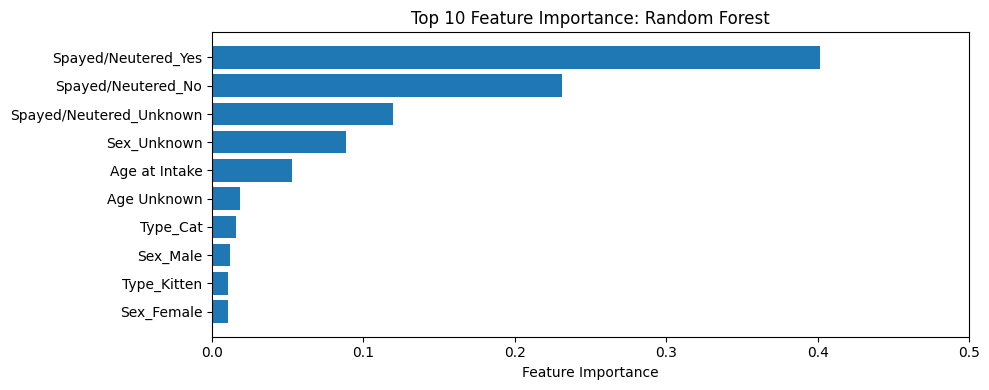

In [74]:
# viz

top_forest = forest_importance.head(10)

plt.figure(figsize=(10,4))
plt.barh(top_forest['Feature'], top_forest['Importance'])
plt.title('Top 10 Feature Importance: Random Forest')
plt.xlabel('Feature Importance')
plt.xlim(0, 0.5)
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Random Forest also identifies **Spayed/Neutered_Yes** as the most important feature - its importance is 0.401. In second place is **Spayed/Neutered_No** (0.231), followed by **Spayed/Neutered_Unknow**n (0.120), **Sex_Unknown** (0.087), and **Age at Intake** (0.053). Unlike the Decision Tree, Random Forest distributes importance across multiple features, as it is built based on a set of trees.

In [75]:
# Random Forest metrics

print('Accuracy:', accuracy_score(y_test, y_pred_forest))
print('Precision:', precision_score(y_test, y_pred_forest))
print('Recall:', recall_score(y_test, y_pred_forest))
print('F1:', f1_score(y_test, y_pred_forest))

Accuracy: 0.920954003407155
Precision: 0.8754863813229572
Recall: 0.9949463044851548
F1: 0.9314015375517445


Random Forest achieved an **accuracy** of 92.1%, **precision** of 87.55%, **recall** of 99.49% and an **F1 score** of 93.14%. The model has a very high recall, meaning it correctly identifies nearly all animals that were actually adopted. Overall, Random Forest performed slightly better, but it was outperformed by the Decision Tree in terms of accuracy and F1 score.

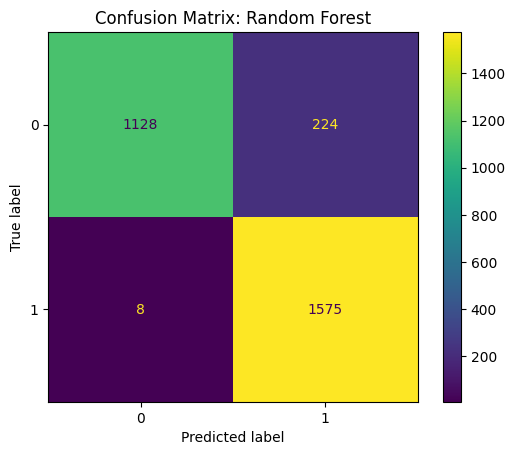

In [76]:
# сonfusion
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_forest)

plt.title('Confusion Matrix: Random Forest')
plt.show()

The confusion matrix shows which predictions the model made correctly and where it made mistakes:

**True Negative** = 1128 - the model correctly predicted "Not Adopted", and the animal was indeed not adopted.

**True Positive** = 1575 - the model correctly predicted "Adopted", and the animal was indeed adopted.

**False Positive** = 224 - the model predicted "Adopted", but the animal was not actually adopted.

**False Negative** = 8 - the model predicted "Not Adopted", even though the animal was actually adopted.

The low number of false negatives explains the high recall 99.49% - the model correctly identifies nearly all animals that were actually adopted



### Model Comparison

In [77]:
# model comparison

model_comparison = pd.DataFrame({
    'Model': [
        'Ridge Logistic Regression',
        'Lasso Logistic Regression',
        'Decision Tree',
        'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_ridge),
        accuracy_score(y_test, y_pred_lasso),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest)],
    'Precision': [
        precision_score(y_test, y_pred_ridge),
        precision_score(y_test, y_pred_lasso),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)],
    'Recall': [
        recall_score(y_test, y_pred_ridge),
        recall_score(y_test, y_pred_lasso),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)],
    'F1': [
        f1_score(y_test, y_pred_ridge),
        f1_score(y_test, y_pred_lasso),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)]})

model_comparison

,Model,Accuracy,Precision,Recall,F1
0,Ridge Logistic Regression,0.920273,0.883021,0.982312,0.930024
1,Lasso Logistic Regression,0.919932,0.874029,0.994946,0.930576
2,Decision Tree,0.922998,0.881823,0.989893,0.932738
3,Random Forest,0.920954,0.875486,0.994946,0.931402


All four models demonstrated high quality and very similar results. The **Decision Tree** model achieved the best results in terms of Accuracy (92.30%) and F1-score (93.27%). Precision also remained high at 88.18%, while Recall was 98.99%.

**Lasso and Random Forest** showed the same Recall 99.49%, but their Accuracy and Precision were slightly lower. Ridge also performed well but fell short of the Decision Tree in terms of Accuracy and F1- score.

Therefore, for further use in the project, we select the **Decision Tree** as the model with the best overall balance of quality.

### Final Model - Adoption Probability Prediction

After comparing the models, we use the selected Decision Tree model to generate a **probability**, rather than only a yes/no classification.

Instead of simply saying "adopted" or "not adopted", the predictor can show an estimated probability such as **76.7%**.

We generate this probability for every cat in the prepared dataset.

In [78]:
# predict adoption probability for all cats

X_all = cats_encoded.drop(columns=['Animal ID', 'Adopted'])

all_proba = tree_model.predict_proba(X_all)

all_proba_df = pd.DataFrame(all_proba, columns=['Not Adopted Prob', 'Adopted Prob'])

all_proba_df.head()

,Not Adopted Prob,Adopted Prob
0,0.010486,0.989514
1,0.010486,0.989514
2,0.010486,0.989514
3,1.000000,0.000000
4,1.000000,0.000000


In [79]:
# keep only adoption probability

all_proba_df = all_proba_df.drop(columns='Not Adopted Prob')

# add Animal ID

all_proba_df['Animal ID'] = cats_encoded['Animal ID'].values

# add probability to main dataset
cats['Adopted Prob'] = all_proba_df['Adopted Prob'].values

cats[['Animal ID', 'Adopted Prob']].head()


,Animal ID,Adopted Prob
0,31530,0.989514
1,32564,0.989514
2,32752,0.989514
3,32881,0.000000
4,32886,0.000000


In [80]:
cats['Adoption Prob %'] = round(cats['Adopted Prob'] * 100, 2)
cats[['Animal ID', 'Adopted Prob', 'Adoption Prob %']].head()

,Animal ID,Adopted Prob,Adoption Prob %
0,31530,0.989514,98.95
1,32564,0.989514,98.95
2,32752,0.989514,98.95
3,32881,0.000000,0.00
4,32886,0.000000,0.00


In [81]:
cats['Adoption Prob %'].describe()

,Adoption Prob %
count,9781.000000
mean,54.086143
std,43.248028
min,0.000000
25%,1.590000
50%,76.670000
75%,98.950000
max,100.000000


The final Decision Tree model generated adoption probabilities for all 9,781 cats. The mean predicted probability of adoption is 54.09%, while the median is 76.67%. The distribution is quite wide, with probabilities ranging from 0% to 100%, indicating that the model assigns very different adoption probabilities to different cats.

In [82]:
#cats.to_csv('cat_adoption.csv', index=False)

#from google.colab import files

#files.download('cat_adoption.csv')

### Model export

The final step is to save the trained model and the preprocessing information needed to reproduce predictions later.

The exported model is used by the prediction API, which is then connected to the Looker Studio dashboard. This turns the notebook from a one-time analysis into the modeling component of an interactive application.

In [83]:
import joblib

joblib.dump(tree_model, 'cat_adoption_tree.pkl')
joblib.dump(list(tree_model.feature_names_in_), 'model_features.pkl')

print(tree_model.feature_names_in_)

['Age at Intake' 'Age Unknown' 'Type_Cat' 'Type_Kitten' 'Sex_Female'
 'Sex_Male' 'Sex_Unknown' 'Spayed/Neutered_No' 'Spayed/Neutered_Unknown'
 'Spayed/Neutered_Yes' 'Primary Breed_American Bobtail'
 'Primary Breed_American Shorthair' 'Primary Breed_Bengal'
 'Primary Breed_British Shorthair' 'Primary Breed_Colorpoint Shorthair'
 'Primary Breed_Domestic Long Hair' 'Primary Breed_Domestic Medium Hair'
 'Primary Breed_Domestic Shorthair' 'Primary Breed_Himalayan'
 'Primary Breed_Maine Coon' 'Primary Breed_Persian'
 'Primary Breed_Ragdoll' 'Primary Breed_Russian'
 'Primary Breed_Russian Blue' 'Primary Breed_Scottish Fold'
 'Primary Breed_Siamese' 'Primary Breed_Snowshoe' 'Primary Breed_Sphynx'
 'Primary Breed_Tonkinese' 'Primary Color_Black'
 'Primary Color_Black Tortoiseshell' 'Primary Color_Blue'
 'Primary Color_Blue Cream Calico'
 'Primary Color_Blue Cream Tortoiseshell' 'Primary Color_Blue Point'
 'Primary Color_Blue Tabby' 'Primary Color_Blue Ticked'
 'Primary Color_Brown' 'Primary Col

In [100]:
def predict_adoption(
    age_months,
    sex,
    spayed_neutered,
    breed,
    primary_color,
    secondary_color,
    intake_month
):
    # create one new cat
    new_cat = pd.DataFrame([{
        'Type': 'Cat',
        'Sex': sex,
        'Spayed/Neutered': spayed_neutered,
        'Primary Breed': breed,
        'Primary Color': primary_color,
        'Secondary Color': secondary_color,
        'Age at Intake': age_months,
        'Age Unknown': 0,
        'Intake Month': intake_month
    }])

    # encode categorical features
    new_cat = pd.get_dummies(
        new_cat,
        columns=[
            'Type',
            'Sex',
            'Spayed/Neutered',
            'Primary Breed',
            'Primary Color',
            'Secondary Color',
            'Intake Month'
        ],
        dtype=int
    )

    # make sure the new cat has exactly the same features as the model was trained on
    new_cat = new_cat.reindex(
        columns=tree_model.feature_names_in_,
        fill_value=0
    )

    # get adoption probability
    probability = tree_model.predict_proba(new_cat)[0, 1]

    return probability

In [101]:
# test
probability = predict_adoption(
    age_months=77,
    sex='Female',
    spayed_neutered='Yes',
    breed='Scotish Fold',
    primary_color='White',
    secondary_color='Unknown',
    intake_month=5
)

print(f"Predicted adoption probability: {probability:.2%}")

Predicted adoption probability: 60.48%


In [102]:
# lists of feature values
print("BREEDS:")
print(cats['Primary Breed'].unique())

print("\nPRIMARY COLORS:")
print(cats['Primary Color'].unique())

print("\nSECONDARY COLORS:")
print(cats['Secondary Color'].unique())

print("\nSEX:")
print(cats['Sex'].unique())

print("\nSPAYED/NEUTERED")
print(cats['Spayed/Neutered'].unique())

BREEDS:
['Domestic Shorthair' 'Domestic Medium Hair' 'Siamese' 'Scottish Fold'
 'Russian' 'Domestic Long Hair' 'Colorpoint Shorthair'
 'American Shorthair' 'Maine Coon' 'Russian Blue' 'Snowshoe' 'Persian'
 'Bengal' 'American Bobtail' 'Sphynx' 'British Shorthair' 'Tonkinese'
 'Ragdoll' 'Himalayan']

PRIMARY COLORS:
['Brown Tabby' 'Black' 'Orange Tabby' 'Smoke' 'Blue' 'Grey Tabby' 'Calico'
 'Grey' 'Cream' 'Tortoiseshell' 'Muted Tortoiseshell' 'White' 'Other'
 'Torbie' 'Brown' 'Buff Tiger' 'Tabby' 'Orange' 'Ginger Tabby'
 'Lilac Point' 'Cream Ginger Tabby' 'Flame Point' 'Smoke Tabby' 'Buff'
 'Seal Point' 'Silver' 'Blue Tabby' 'Silver Tortoiseshell' 'Lynx Point'
 'Muted Calico' 'Brown Tiger' 'Silver Tabby' 'Tabby Point' 'Torti Point'
 'Black Tortoiseshell' 'Unknown' 'Blue Cream Calico'
 'Blue Cream Tortoiseshell' 'Blue Point' 'Chocolate' 'Blue Ticked']

SECONDARY COLORS:
['Unknown' 'Brown Tabby' 'White' 'Orange Tabby' 'Black' 'Smoke' 'Tabby'
 'Tortoiseshell' 'Grey' 'Brown' 'Muted Calico' '

In [104]:
# values for the prediction form

breeds = sorted(cats['Primary Breed'].unique())
primary_colors = sorted(cats['Primary Color'].unique())
secondary_colors = sorted(cats['Secondary Color'].unique())

sex_options = ['Female', 'Male', 'Unknown']
spayed_options = ['Yes', 'No', 'Unknown']

month_options = list(range(1, 13))

In [103]:
!pip install ipywidgets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.8 MB/s eta 0:00:00


In [105]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Age
age_input = widgets.IntText(
    value=8,
    description='Age:',
    min=0
)

# Dropdowns
sex_input = widgets.Dropdown(
    options=['Female', 'Male', 'Unknown'],
    value='Female',
    description='Sex:'
)

spayed_input = widgets.Dropdown(
    options=['Yes', 'No', 'Unknown'],
    value='Yes',
    description='Spayed:'
)

breed_input = widgets.Dropdown(
    options=breeds,
    value='Sphynx',
    description='Breed:'
)

primary_color_input = widgets.Dropdown(
    options=primary_colors,
    value='White',
    description='Primary color:'
)

secondary_color_input = widgets.Dropdown(
    options=secondary_colors,
    value='Unknown',
    description='Secondary color:'
)

month_input = widgets.Dropdown(
    options=list(range(1, 13)),
    value=9,
    description='Intake month:'
)

# Button
predict_button = widgets.Button(
    description='Predict Adoption Probability',
    button_style='success'
)

# Output area
output = widgets.Output()


def on_predict_clicked(b):
    with output:
        clear_output()

        probability = predict_adoption(
            age_months=age_input.value,
            sex=sex_input.value,
            spayed_neutered=spayed_input.value,
            breed=breed_input.value,
            primary_color=primary_color_input.value,
            secondary_color=secondary_color_input.value,
            intake_month=month_input.value
        )

        print(f"Predicted adoption probability: {probability:.2%}")


predict_button.on_click(on_predict_clicked)

# Display form
display(
    age_input,
    sex_input,
    spayed_input,
    breed_input,
    primary_color_input,
    secondary_color_input,
    month_input,
    predict_button,
    output
)

IntText(value=8, description='Age:')

Dropdown(description='Sex:', options=('Female', 'Male', 'Unknown'), value='Female')

Dropdown(description='Spayed:', options=('Yes', 'No', 'Unknown'), value='Yes')

Dropdown(description='Breed:', index=17, options=('American Bobtail', 'American Shorthair', 'Bengal', 'British…

Dropdown(description='Primary color:', index=40, options=('Black', 'Black Tortoiseshell', 'Blue', 'Blue Cream …

Dropdown(description='Secondary color:', index=21, options=('Black', 'Black Tortoiseshell', 'Blue', 'Blue Tabb…

Dropdown(description='Intake month:', index=8, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12), value=9)

Button(button_style='success', description='Predict Adoption Probability', style=ButtonStyle())

Output()

In [106]:
# import

import joblib
import zipfile
from google.colab import files

# ==========================================
# 1. Save the trained model
# ==========================================

joblib.dump(tree_model, 'cat_adoption_tree.pkl')

# Save the exact feature names expected by the model
joblib.dump(
    list(tree_model.feature_names_in_),
    'model_features.pkl'
)


# ==========================================
# 2. Create app.py
# ==========================================

app_code = '''
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import pandas as pd
import joblib


# Load model and feature schema
model = joblib.load("cat_adoption_tree.pkl")
MODEL_FEATURES = joblib.load("model_features.pkl")


app = FastAPI(
    title="Cat Adoption Prediction API"
)


# Input data for a new cat
class CatInput(BaseModel):

    age_months: int = Field(..., ge=0)

    sex: str

    spayed_neutered: str

    breed: str

    primary_color: str

    secondary_color: str

    intake_month: int = Field(..., ge=1, le=12)


# Get allowed categories from model features
def get_allowed_values(prefix):

    return [
        column.replace(prefix, "", 1)
        for column in MODEL_FEATURES
        if column.startswith(prefix)
    ]


ALLOWED_SEX = get_allowed_values("Sex_")

ALLOWED_SPAYED = get_allowed_values(
    "Spayed/Neutered_"
)

ALLOWED_BREEDS = get_allowed_values(
    "Primary Breed_"
)

ALLOWED_PRIMARY_COLORS = get_allowed_values(
    "Primary Color_"
)

ALLOWED_SECONDARY_COLORS = get_allowed_values(
    "Secondary Color_"
)


# Prediction function
def predict_adoption(data: CatInput):

    # Type is fixed because this predictor is for cats
    new_cat = pd.DataFrame([{

        "Type": "Cat",

        "Sex": data.sex,

        "Spayed/Neutered": data.spayed_neutered,

        "Primary Breed": data.breed,

        "Primary Color": data.primary_color,

        "Secondary Color": data.secondary_color,

        "Age at Intake": data.age_months,

        "Age Unknown": 0,

        "Intake Month": data.intake_month

    }])


    # Validate categories
    checks = {

        "sex": (
            data.sex,
            ALLOWED_SEX
        ),

        "spayed_neutered": (
            data.spayed_neutered,
            ALLOWED_SPAYED
        ),

        "breed": (
            data.breed,
            ALLOWED_BREEDS
        ),

        "primary_color": (
            data.primary_color,
            ALLOWED_PRIMARY_COLORS
        ),

        "secondary_color": (
            data.secondary_color,
            ALLOWED_SECONDARY_COLORS
        )

    }


    for field, (value, allowed) in checks.items():

        if value not in allowed:

            raise HTTPException(
                status_code=400,
                detail=f"Invalid {field}. Allowed values: {allowed}"
            )


    # Same one-hot encoding as during training
    new_cat = pd.get_dummies(
        new_cat,

        columns=[
            "Type",
            "Sex",
            "Spayed/Neutered",
            "Primary Breed",
            "Primary Color",
            "Secondary Color",
            "Intake Month"
        ],

        dtype=int
    )


    # Make columns exactly match the trained model
    new_cat = new_cat.reindex(
        columns=MODEL_FEATURES,
        fill_value=0
    )


    # Get probability
    probability = model.predict_proba(
        new_cat
    )[0, 1]


    return probability


# Home endpoint
@app.get("/")
def home():

    return {
        "status": "ok",
        "message": "Cat adoption prediction API is running."
    }


# Prediction endpoint
@app.post("/predict")
def predict(data: CatInput):

    probability = predict_adoption(data)

    return {

        "adoption_probability":
            round(float(probability), 6),

        "adoption_probability_percent":
            round(float(probability) * 100, 2)

    }
'''


with open("app.py", "w") as f:
    f.write(app_code)


# ==========================================
# 3. Create requirements.txt
# ==========================================

requirements = """
fastapi
uvicorn
pandas
scikit-learn
joblib
pydantic
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())


# ==========================================
# 4. Create ZIP archive
# ==========================================

files_to_zip = [
    "app.py",
    "requirements.txt",
    "cat_adoption_tree.pkl",
    "model_features.pkl"
]

with zipfile.ZipFile(
    "cat_adoption_api.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in files_to_zip:
        zip_file.write(file)


# ==========================================
# 5. Download everything
# ==========================================

print("Everything is ready!")

print("\nFiles inside the archive:")

for file in files_to_zip:
    print("✓", file)

files.download("cat_adoption_api.zip")

Everything is ready!

Files inside the archive:
✓ app.py
✓ requirements.txt
✓ cat_adoption_tree.pkl
✓ model_features.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>